# Analyse de la Folksonomie de Steam

## Objectif
L'objectif de ce notebook est d'explorer la structure des tags utilisateurs (folksonomie) sur Steam. Nous cherchons à comprendre comment les tags sont distribués, à identifier le bruit potentiel (tags rares ou non pertinents) et à découvrir des relations fortes entre les tags existants. Cette analyse servira de base pour **guider la création d'une taxonomie de gameplay plus cohérente et structurée**.

Nous allons procéder en plusieurs étapes :
1.  **Exploration des données** : Connexion à la base de données et inspection des tables.
2.  **Analyse descriptive** : Statistiques sur les jeux et les tags (fréquence, distribution).
3.  **Filtrage du bruit** : Identification et élimination des tags trop rares.
4.  **Règles d'association** : Utilisation de l'algorithme FP-Growth pour trouver des liens logiques entre les tags (ex: "Si RPG, alors souvent Fantasy").
5.  **Visualisation** : Représentation graphique des relations pour mieux interpréter les résultats.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx

# Chemin vers votre fichier .db
db_path = '../data/2024-12-13.steam.db'

# Création de la connexion
conn = sqlite3.connect(db_path)

# 1. Récupérer la liste des tables présentes dans la base
query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query_tables, conn)

print("Tables trouvées dans la base de données :")
print(tables)

# 2. Inspecter le schéma de chaque table (pour comprendre les colonnes)
for table_name in tables['name']:
    print(f"\n--- Schéma de la table : {table_name} ---")
    # Récupère les infos sur les colonnes (cid, name, type, notnull, etc.)
    schema = pd.read_sql_query(f"PRAGMA table_info({table_name})", conn)
    print(schema[['name', 'type']])

    # 3. Afficher les 5 premières lignes pour visualiser le contenu
    print(f"--- Aperçu des données ({table_name}) ---")
    preview = pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 5", conn)
    print(preview)


conn.close() # Pour bloquer la connexion à la db

Tables trouvées dans la base de données :
               name
0             games
1   sqlite_sequence
2           studios
3        categories
4            genres
5     game_category
6        game_genre
7        publishers
8        developers
9          game_tag
10             tags

--- Schéma de la table : games ---
               name     type
0                id  INTEGER
1             appid  INTEGER
2              name     TEXT
3         metascore  INTEGER
4              date     TEXT
5  nbRecommandation  INTEGER
--- Aperçu des données (games) ---
   id    appid                         name  metascore    date  \
0   1  1000030  Cook, Serve, Delicious! 3?!         79  201014   
1   2  1000360                Hellish Quart         -1  210216   
2   3  1000600                The ScreaMaze         -1  190110   
3   4  1000640                     Clam Man         -1  190523   
4   5  1000650        Fist Of Heaven & Hell         -1  190628   

   nbRecommandation  
0              1606  
1  

### Sélection des données pertinentes
Après inspection du schéma de la base de données, nous avons identifié les tables clés pour notre analyse :
 - `games` : Contient les métadonnées des jeux (ID, nom, etc.).
 - `tags` : Contient le vocabulaire des tags (ID, libellé).
 - `game_tag` : Table de liaison qui associe les jeux aux tags. Elle contient une colonne cruciale `pos` (position), qui indique le rang du tag pour un jeu donné (0 = tag le plus voté/pertinent, 1 = le second, etc.).

Nous allons maintenant extraire ces données dans un DataFrame unique pour faciliter l'analyse.

In [2]:
# Chemin vers votre fichier .db
db_path = '../data/2024-12-13.steam.db'

# Création de la connexion
conn = sqlite3.connect(db_path)

# Requête optimisée pour récupérer les jeux et leurs tags associés
# Nous incluons 'pos' car ce sera votre filtre principal contre le bruit
sql_query = """
SELECT
    g.id as game_id,
    g.name as game_title,
    t.label as tag_label,
    gt.pos as tag_rank
FROM games g
JOIN game_tag gt ON g.id = gt.game_id
JOIN tags t ON t.id = gt.tag_id
"""

print("Chargement des données...")
df = pd.read_sql_query(sql_query, conn)
conn.close()

print(f"Chargement terminé. {df.shape[0]} associations récupérées.")
print(df.head())

Chargement des données...
Chargement terminé. 1491503 associations récupérées.
   game_id    game_title   tag_label  tag_rank
0   106127  The Platform      Action         0
1   106127  The Platform      Casual         1
2   106127  The Platform  Simulation         2
3   106127  The Platform  2D Fighter         3
4   106127  The Platform  3D Fighter         4


In [3]:
# Configuration pour des graphiques lisibles
sns.set_theme(style="whitegrid")

# 1. Connexion à la base
db_path = '../data/2024-12-13.steam.db'
conn = sqlite3.connect(db_path)

# 2. Requête d'extraction focalisée sur la folksonomie
# On récupère le nom du jeu, le tag, et surtout le 'pos' (classement du tag)
query = """
SELECT
    g.name as game_name,
    t.label as tag_label,
    gt.pos as tag_rank
FROM game_tag gt
JOIN games g ON gt.game_id = g.id
JOIN tags t ON gt.tag_id = t.id
"""

print("Chargement des données en cours...")
df = pd.read_sql_query(query, conn)
conn.close()

# 3. Affichage des premières statistiques
n_games = df['game_name'].nunique()
n_tags = df['tag_label'].nunique()
n_associations = len(df)

print(f"--- Volumétrie Globale ---")
print(f"Nombre total de jeux : {n_games}")
print(f"Nombre total de tags uniques (vocabulaire) : {n_tags}")
print(f"Nombre total d'associations (jeu-tag) : {n_associations}")
print(f"Moyenne de tags par jeu : {n_associations / n_games:.2f}")

# Aperçu du dataset
df.head()

Chargement des données en cours...
--- Volumétrie Globale ---
Nombre total de jeux : 100473
Nombre total de tags uniques (vocabulaire) : 448
Nombre total d'associations (jeu-tag) : 1491503
Moyenne de tags par jeu : 14.84


,game_name,tag_label,tag_rank
0,The Platform,Action,0
1,The Platform,Casual,1
2,The Platform,Simulation,2
3,The Platform,2D Fighter,3
4,The Platform,3D Fighter,4


### Analyse Volumétrique
Les chiffres ci-dessus nous donnent une première vue d'ensemble :
  - **~100k jeux** : Une base de données conséquente.
  - **~450 tags uniques** : Un vocabulaire relativement restreint par rapport au nombre de jeux, ce qui est bon signe pour la classification (moins de dispersion que prévu).
  - **~15 tags par jeu** en moyenne : C'est beaucoup. Cela suggère que les jeux sont décrits de manière très (trop ?) détaillée, mélangeant probablement genres, mécaniques, ambiance et thèmes.

Regardons maintenant la distribution de ces tags : quels sont les plus populaires ?

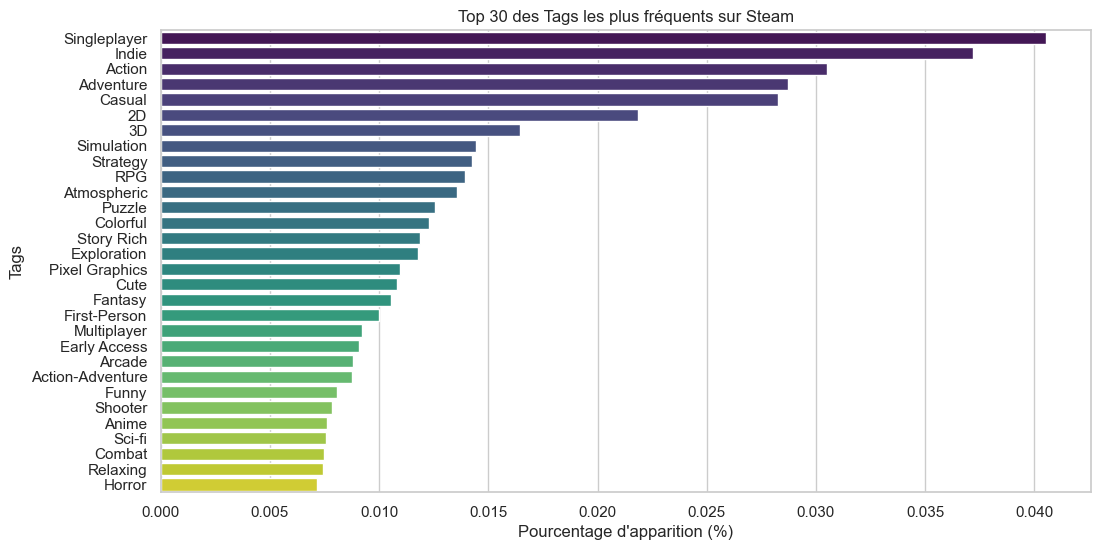

--- Analyse du Bruit ---
Tags apparaissant 1 seule fois : 0
Pourcentage du vocabulaire potentiellement 'inutile' : 0.00%


In [4]:
# 1. Calcul de la fréquence de chaque tag
tag_counts = df['tag_label'].value_counts()

# 2. Visualisation des 30 tags les plus fréquents
plt.figure(figsize=(12, 6))
# Correction du warning Seaborn : on assigne x à hue et on désactive la légende
sns.barplot(x=tag_counts.head(30).values/ n_associations, y=tag_counts.head(30).index, hue=tag_counts.head(30).index, palette="viridis", legend=False)
plt.title("Top 30 des Tags les plus fréquents sur Steam")
plt.xlabel("Pourcentage d'apparition (%)")
plt.ylabel("Tags")
plt.show()

# 3. Analyse de la "Long Tail" (Queue de distribution)
# Combien de tags n'apparaissent qu'une seule fois ?
tags_single_use = tag_counts[tag_counts == 1].count()
percent_noise = (tags_single_use / n_tags) * 100

print(f"--- Analyse du Bruit ---")
print(f"Tags apparaissant 1 seule fois : {tags_single_use}")
print(f"Pourcentage du vocabulaire potentiellement 'inutile' : {percent_noise:.2f}%")

### Constat sur la distribution (Loi de Pareto)
Le graphique ci-dessus confirme une distribution classique en "loi de Pareto" :
  - Une poignée de tags "génériques" (Indie, Action, Adventure) dominent largement et sont présents sur une immense partie du catalogue. Ils sont utiles pour une catégorisation large mais peu discriminants pour une analyse fine de gameplay.
  - À l'inverse, il existe une "longue traîne" (long tail) de tags très spécifiques ou rares.
  - Le pourcentage de tags apparaissant une seule fois nous donne une idée du "bruit" pur dans la folksonomie.

Nous allons maintenant regarder la colonne `pos` (rang du tag) pour voir si les tags les plus pertinents sont bien placés en premier.

--- Analyse de la pertinence (Position des tags) ---
count    1.491503e+06
mean     8.148763e+00
std      5.595627e+00
min      0.000000e+00
25%      3.000000e+00
50%      8.000000e+00
75%      1.300000e+01
max      1.900000e+01
Name: tag_rank, dtype: float64


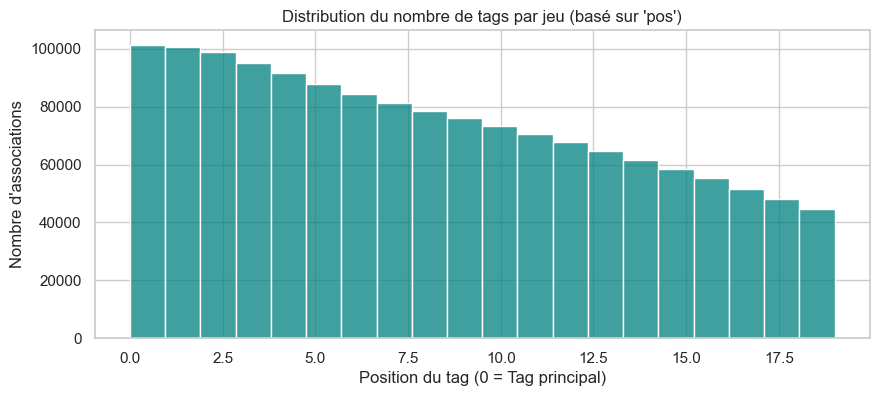


--- Exemple de transaction (Jeu 1) ---
Tags bruts : ['Action', 'Simulation', 'Action-Adventure', 'Shooter', 'FPS', '3D', 'First-Person', 'Realistic', 'Dinosaurs', 'Survival', 'Artificial Intelligence', 'Combat', 'Singleplayer', 'Casual', 'Exploration', 'Indie', 'Point & Click', 'Clicker', '2D', 'Colorful', 'Cute', 'Minimalist', 'Relaxing', 'Nonlinear', 'Singleplayer', 'Action', 'Indie', 'Simulation', 'Strategy', 'Action', 'Horror', 'Casual', 'Adventure', 'Action', 'RPG', 'Action-Adventure', 'Action RPG', 'Strategy', 'Exploration', 'Relaxing', 'Alternate History', 'Funny', 'Action Roguelike', 'Singleplayer', 'Traditional Roguelike', 'Bullet Hell', 'Third-Person Shooter', '2D', 'Pixel Graphics', 'Psychological Horror', 'Survival', 'Indie', 'Space', 'Arcade', 'Action', 'Adventure', 'RPG', 'Indie', 'Strategy', 'RPG', 'Card Game', 'Turn-Based Strategy', 'Party-Based RPG', 'City Builder', 'Grand Strategy', 'Card Battler', 'Wargame', 'Tactical RPG', 'Trading Card Game', '2D', 'VR', 'Military

In [5]:
# 1. Analyse de la colonne 'pos' (Ranking)
print("--- Analyse de la pertinence (Position des tags) ---")
print(df['tag_rank'].describe())

# Visualisation de la distribution des rangs
plt.figure(figsize=(10, 4))
sns.histplot(df['tag_rank'], bins=20, kde=False, color="teal")
plt.title("Distribution du nombre de tags par jeu (basé sur 'pos')")
plt.xlabel("Position du tag (0 = Tag principal)")
plt.ylabel("Nombre d'associations")
plt.show()

# 2. Préparation pour les Règles d'Association (Format Transactionnel)
# L'algo a besoin d'une liste de listes : [ ['Action', 'FPS'], ['RPG', 'Indie'], ... ]

# On groupe les tags par jeu
transactions = df.groupby('game_name')['tag_label'].apply(list).tolist()

print(f"\n--- Exemple de transaction (Jeu 1) ---")
print(f"Tags bruts : {transactions[0]}")
print(f"Nombre total de transactions (jeux) : {len(transactions)}")

### Recherche de Règles d'Association (Mining)
Nous allons maintenant utiliser des techniques de fouille de données (Data Mining) pour découvrir les relations cachées entre les tags.
L'objectif est de trouver des règles du type : **"Si un jeu a le tag A, alors il a aussi le tag B"**.

Pour cela, nous utilisons l'algorithme **FP-Growth** (Frequent Pattern Growth), qui est plus efficace en mémoire que l'algorithme Apriori classique pour les grands jeux de données.

**Stratégie de nettoyage :**
Avant de lancer l'algorithme, nous allons filtrer les tags trop rares (apparaissant dans moins de 1% des jeux). Cela permet de :
1.  Réduire drastiquement la consommation mémoire.
2.  Éliminer les règles anecdotiques basées sur des micro-niches, pour se concentrer sur les structures de gameplay majeures.

In [6]:
# --- OPTIMISATION MÉMOIRE ---
# Le dataset est trop grand pour Apriori brut.
# Stratégie :
# 1. Filtrer les tags rares AVANT l'encodage (réduit le nombre de colonnes)
# 2. Utiliser FP-Growth (plus efficace en mémoire que Apriori)
# 3. Utiliser un encodage Sparse si nécessaire (ici on filtre d'abord)

# Seuil : On ne garde que les tags qui apparaissent dans au moins 1% des jeux
min_support_count = df['game_name'].nunique() * 0.01
print(f"Filtrage des tags : on garde ceux apparaissant dans au moins {int(min_support_count)} jeux.")

tag_counts = df['tag_label'].value_counts()
valid_tags = tag_counts[tag_counts >= min_support_count].index

# Filtrage du DataFrame source
df_filtered = df[df['tag_label'].isin(valid_tags)]
print(f"Nombre de tags uniques après filtrage : {df_filtered['tag_label'].nunique()} (sur {df['tag_label'].nunique()} initialement)")

# Recalcul des transactions sur les données filtrées
transactions_filtered = df_filtered.groupby('game_name')['tag_label'].apply(list).tolist()

# 1. Encodage des transactions
te = TransactionEncoder()
te_ary = te.fit(transactions_filtered).transform(transactions_filtered)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Encodage terminé.")
print(f"Dimensions du DataFrame encodé : {df_encoded.shape}")

# 2. Algorithme FP-Growth
# FP-Growth est beaucoup plus rapide et économe en mémoire que Apriori pour les grands datasets
frequent_itemsets = fpgrowth(df_encoded, min_support=0.02, use_colnames=True)

print(f"\nNombre d'itemsets fréquents trouvés : {len(frequent_itemsets)}")
print("Top 10 des itemsets les plus fréquents :")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

# 3. Règles d'association
# On cherche les règles avec un 'lift' > 1.2
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Tri par lift décroissant
rules = rules.sort_values(by='lift', ascending=False)

# Préparation des colonnes string pour les visualisations suivantes
rules['ant_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['con_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"\nNombre de règles générées : {len(rules)}")
print("Top 10 des règles les plus fortes :")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Filtrage des tags : on garde ceux apparaissant dans au moins 1004 jeux.
Nombre de tags uniques après filtrage : 236 (sur 448 initialement)
Encodage terminé.
Dimensions du DataFrame encodé : (100325, 236)

Nombre d'itemsets fréquents trouvés : 2902
Top 10 des itemsets les plus fréquents :
      support                              itemsets
0    0.599223             frozenset({Singleplayer})
1    0.549125                    frozenset({Indie})
2    0.450755                   frozenset({Action})
3    0.424620                frozenset({Adventure})
4    0.418500                   frozenset({Casual})
174  0.355694      frozenset({Indie, Singleplayer})
5    0.323828                       frozenset({2D})
178  0.272255  frozenset({Singleplayer, Adventure})
175  0.261381     frozenset({Action, Singleplayer})
185  0.260812     frozenset({Casual, Singleplayer})

Nombre de règles générées : 12402
Top 10 des règles les plus fortes :
                                      antecedents  \
8946          f

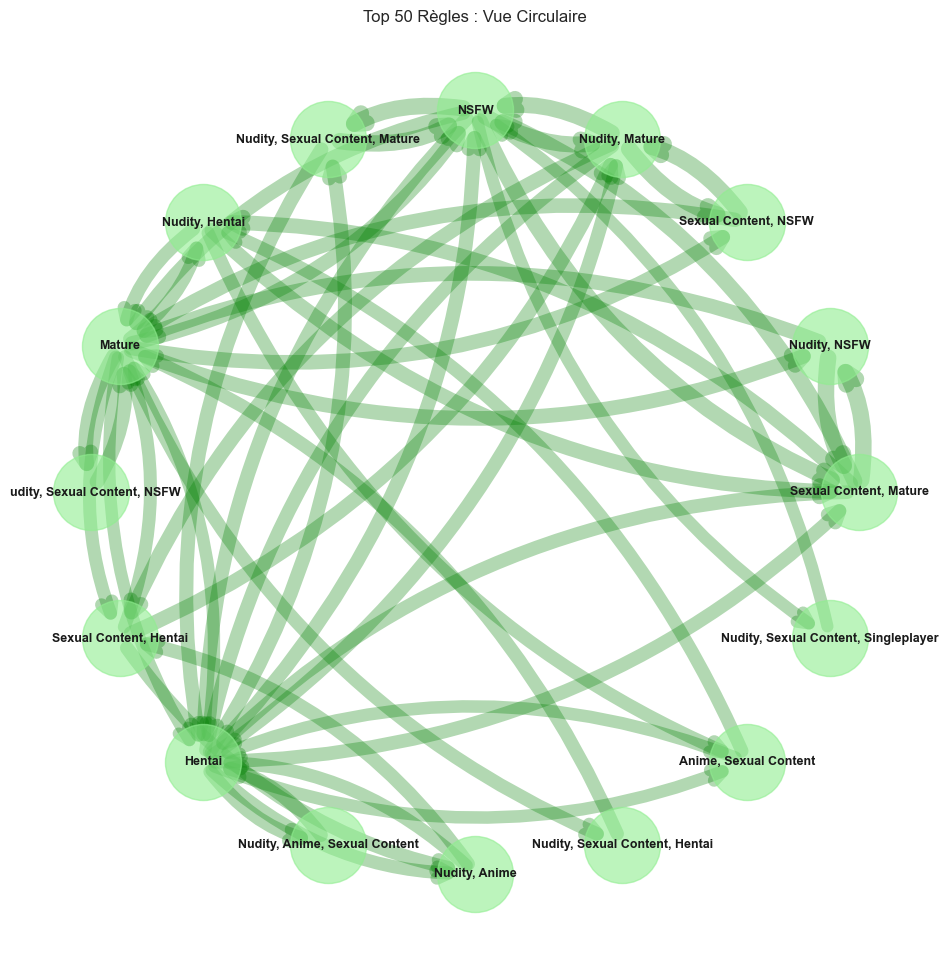

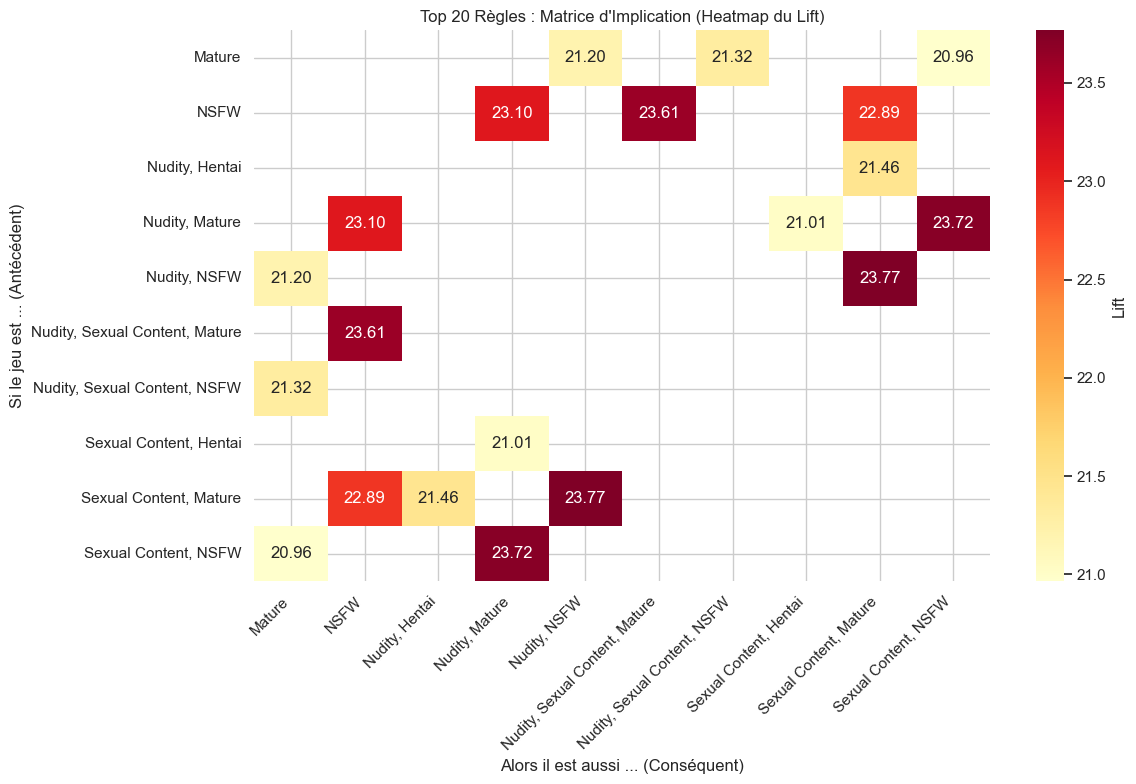

In [7]:
# VISUALISATION DES RÈGLES

# 1. Graphe Circulaire (Circular Layout)
# On analyse les règle d'associations pour les 50 premier tags, pour pouvoir garder une certaine visibilité

plt.figure(figsize=(12, 12))
top_rules_plot = rules.sort_values('lift', ascending=False).head(50)
G = nx.DiGraph()
for i, row in top_rules_plot.iterrows():
    G.add_edge(row['ant_str'], row['con_str'], weight=row['lift'])

pos_circ = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos_circ, node_size=3000, node_color="lightgreen", alpha=0.6)
nx.draw_networkx_edges(G, pos_circ, width=[G[u][v]['weight']*0.5 for u,v in G.edges()],
                       edge_color="green", alpha=0.3, arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=0.2')
nx.draw_networkx_labels(G, pos_circ, font_size=9, font_weight="bold")

plt.title("Top 50 Règles : Vue Circulaire")
plt.axis('off')
plt.show()

# 2. Heatmap (Matrice de Corrélation des Règles)
# Cette vue permet de voir rapidement quels antécédents déclenchent quels conséquents avec force.

# On filtre pour garder les règles les plus pertinentes (Top 20 par Lift) pour que la matrice soit lisible
top_rules_matrix = rules.sort_values('lift', ascending=False).head(20)

# Création de la matrice pivot (Antécédent en lignes, Conséquent en colonnes, Valeur = Lift)
# Si plusieurs règles ont les mêmes ant/con (peu probable ici car unique), pivot gère ça.
pivot_matrix = top_rules_matrix.pivot(index='ant_str', columns='con_str', values='lift')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_matrix, annot=True, cmap="YlOrRd", fmt=".2f", cbar_kws={'label': 'Lift'})
plt.title("Top 20 Règles : Matrice d'Implication (Heatmap du Lift)")
plt.ylabel("Si le jeu est ... (Antécédent)")
plt.xlabel("Alors il est aussi ... (Conséquent)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyse des Visualisations
**Graphe Circulaire** :
Ce graphe montre les liens les plus forts (Top 50 par Lift). On observe souvent des clusters isolés ou des "hubs".
*Observation* : On remarque qu'un groupe de règles d'association est particulièrement dense et isolé, souvent associé au contenu "NSFW" (Not Safe For Work) ou "Hentai". Ces tags forment une communauté très fermée qui interagit peu avec les tags de gameplay classiques (Strategy, RPG, etc.).

**Heatmap** :
La matrice confirme cette tendance. Les zones rouge foncé indiquent des implications quasi-systématiques. Cela nous aide à repérer les synonymes ou les sous-genres très marqués.


--- Top 10 Règles par SUPPORT (Les plus fréquentes) ---
                    ant_str               con_str   support  confidence  \
19                       2D          Singleplayer  0.246050    0.759819   
18             Singleplayer                    2D  0.246050    0.410616   
3                     Indie  Casual, Singleplayer  0.174483    0.317747   
2      Casual, Singleplayer                 Indie  0.174483    0.668998   
21                Indie, 2D          Singleplayer  0.158734    0.872125   
22             Singleplayer             Indie, 2D  0.158734    0.264900   
20      Indie, Singleplayer                    2D  0.158734    0.446266   
23                       2D   Indie, Singleplayer  0.158734    0.490181   
10148          Singleplayer           Atmospheric  0.148158    0.247251   
10149           Atmospheric          Singleplayer  0.148158    0.737741   

           lift  
19     1.268008  
18     1.268008  
3      1.218297  
2      1.218297  
21     1.455427  
22     1.

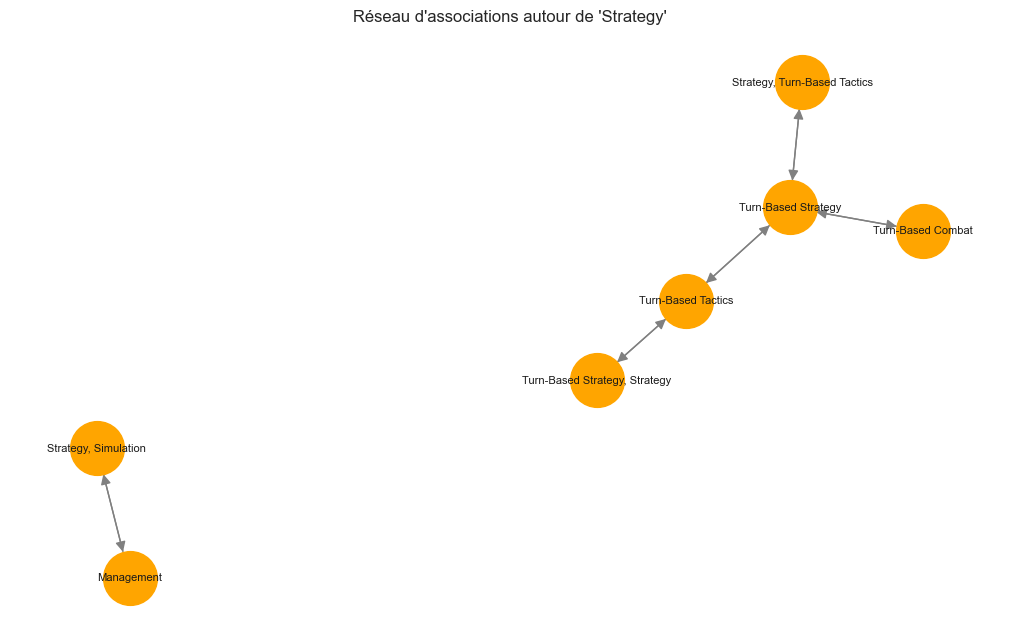

In [8]:
# EXPLORATION DIVERSIFIÉE

# Le tri par 'Lift' montre souvent des niches très spécifiques.
# Regardons d'autres métriques pour voir des règles plus "Mainstream".

# A. Top Règles par SUPPORT (Les associations les plus fréquentes dans l'absolu)
top_support = rules.sort_values('support', ascending=False).head(10)
print("\n--- Top 10 Règles par SUPPORT (Les plus fréquentes) ---")
print(top_support[['ant_str', 'con_str', 'support', 'confidence', 'lift']])

# B. Top Règles par CONFIDENCE (Les prédictions les plus sûres)
# On filtre un minimum de support pour éviter les règles basées sur 1 seul jeu
top_conf = rules[rules['support'] > 0.05].sort_values('confidence', ascending=False).head(10)
print("\n--- Top 10 Règles par CONFIDENCE (Support > 5%) ---")
print(top_conf[['ant_str', 'con_str', 'support', 'confidence', 'lift']])

# C. Focus sur un Tag spécifique (Exemple : 'Strategy')
target_tag = 'Strategy'

# On cherche les règles où le tag est dans l'antécédent OU le conséquent
mask = rules['ant_str'].str.contains(target_tag) | rules['con_str'].str.contains(target_tag)
target_rules = rules[mask].sort_values('lift', ascending=False).head(10)

print(f"\n--- Top 10 Règles impliquant '{target_tag}' ---")
if not target_rules.empty:
    print(target_rules[['ant_str', 'con_str', 'support', 'confidence', 'lift']])
    
    # Petit graphe spécifique pour ce tag
    G_target = nx.DiGraph()
    for i, row in target_rules.iterrows():
        G_target.add_edge(row['ant_str'], row['con_str'], weight=row['lift'])
    
    plt.figure(figsize=(10, 6))
    pos_t = nx.spring_layout(G_target, seed=42)
    nx.draw(G_target, pos_t, with_labels=True, node_color='orange', node_size=1500, font_size=8, edge_color='gray', arrowsize=15)
    plt.title(f"Réseau d'associations autour de '{target_tag}'")
    plt.show()
else:
    print(f"Aucune règle trouvée pour '{target_tag}' avec les seuils actuels.")


### Limites de l'approche actuelle
Bien que cette recherche soit intéressante, elle présente des limites pour une vision globale :
1.  **Dominance des niches** : Les algorithmes basés sur le *Lift* ont tendance à mettre en avant des petites communautés très soudées (comme les jeux NSFW ou certains types de Puzzle) au détriment des grands genres.
2.  **Manque de hiérarchie** : Les règles d'association sont "plates" (A implique B). Elles ne nous disent pas si A est un sous-genre de B ou juste un voisin.
3.  **Bruit persistant** : Malgré le filtrage, la polysémie de certains tags (ex: "Action" qui veut tout et rien dire) brouille les pistes.

### Conclusion et Prochaines étapes
Sans un réaménagement structurel de la base de données ou une approche plus supervisée, il est difficile de faire émerger automatiquement une taxonomie propre uniquement via les règles d'association.

Pour la suite, nous recommandons :
- De **catégoriser manuellement** ou semi-automatiquement les tags en "Familles" (Gameplay, Ambiance, Vue, Thème).
- D'utiliser ces familles pour filtrer les associations (ex: ne chercher des liens que *entre* tags de Gameplay).
- D'envisager des méthodes de **Clustering** (K-Means, Louvain) sur le graphe des tags pour détecter des communautés plus larges que de simples paires.
